
# Modelos de pronóstico para series de tiempo

Una **serie de tiempo** es una secuencia de datos ordenados en el tiempo, recolectados en intervalos regulares (como cada hora, día, mes o año). Su característica fundamental es que el orden temporal es crucial, ya que las observaciones suelen estar correlacionadas con sus valores pasados (dependencia temporal).

## Diferencias entre modelos de pronóstico y modelos de regresión convencionales:

La diferencia principal radica en la **estructura de los datos y la naturaleza de la relación entre las variables**.

| Característica | Modelos de Regresión Convencionales | Modelos de Pronóstico de Series de Tiempo |
| :--- | :--- | :--- |
| **Supuesto Central** | Las observaciones son **independientes** entre sí. | Las observaciones son **dependientes** (autocorrelación). El valor pasado influye en el futuro. |
| **Relación con el Tiempo** | El tiempo suele ser irrelevante o es solo una variable explicativa más (ej: `edad`). | El tiempo es la **dimensión fundamental**. El objetivo es modelar explícitamente la estructura temporal. |
| **Variables de Entrada** | Usa variables predictoras independientes (ej: `tamaño`, `ingresos`) para predecir una variable objetivo. | Usa principalmente el **historial de la propia serie** (valores rezagados, tendencia, estacionalidad) como predictores. |
| **Propósito** | Explicar o predecir una variable en función de **otras** variables. | Predecir valores **futuros** de la misma variable, extrapolando su patrón histórico. |

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trm = pd.read_excel('/content/1.1.1.TCM_Serie histórica IQY.xlsx', header=7 )
trm.drop(trm.tail(4).index, axis=0, inplace=True)
trm.rename({trm.columns[0]:'Fecha', trm.columns[1]:'TRM'}, axis=1, inplace=True)
trm['Fecha'] = pd.to_datetime(trm['Fecha'], dayfirst=True)
trm.set_index('Fecha', inplace=True)
trm = trm.asfreq('B')
trm.head()

,TRM
Fecha,
1991-11-27,693.32
1991-11-28,693.99
1991-11-29,694.70
1991-12-02,643.42
1991-12-03,639.22


In [10]:
trm.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8426 entries, 1991-11-27 to 2024-03-13
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TRM     8426 non-null   float64
dtypes: float64(1)
memory usage: 131.7 KB


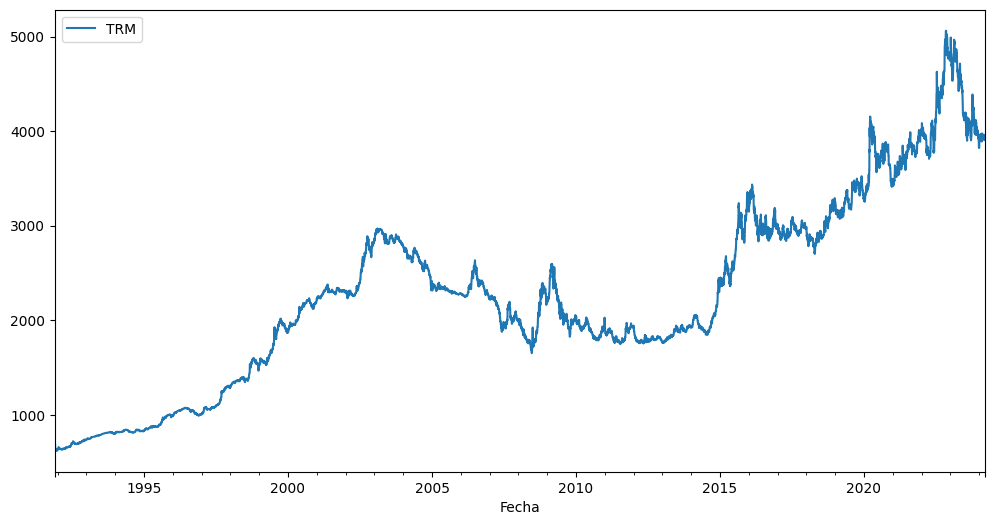

In [5]:
trm.plot(figsize=(12, 6));

## Feature extraction


Vamos a empezar creando nuevas características con los retardos, que son los valores que toma la serie en los periodos anteriores.

In [11]:
retardo = 30
for i in range(1, retardo+1):
    trm['TRM-'+str(i)] = trm['TRM'].shift(i)
trm.dropna(inplace=True)
trm.head()

,TRM,TRM-1,TRM-2,TRM-3,TRM-4,TRM-5,TRM-6,TRM-7,TRM-8,TRM-9,...,TRM-21,TRM-22,TRM-23,TRM-24,TRM-25,TRM-26,TRM-27,TRM-28,TRM-29,TRM-30
Fecha,,,,,,,,,,,,,,,,,,,,,
1992-01-08,638.17,638.07,638.07,632.58,638.61,632.37,632.37,632.37,631.63,622.95,...,622.92,638.06,627.16,631.51,635.70,639.22,643.42,694.70,693.99,693.32
1992-01-09,638.61,638.17,638.07,638.07,632.58,638.61,632.37,632.37,632.37,631.63,...,627.46,622.92,638.06,627.16,631.51,635.70,639.22,643.42,694.70,693.99
1992-01-10,637.86,638.61,638.17,638.07,638.07,632.58,638.61,632.37,632.37,632.37,...,633.09,627.46,622.92,638.06,627.16,631.51,635.70,639.22,643.42,694.70
1992-01-13,645.04,637.86,638.61,638.17,638.07,638.07,632.58,638.61,632.37,632.37,...,632.35,633.09,627.46,622.92,638.06,627.16,631.51,635.70,639.22,643.42
1992-01-14,659.74,645.04,637.86,638.61,638.17,638.07,638.07,632.58,638.61,632.37,...,630.91,632.35,633.09,627.46,622.92,638.06,627.16,631.51,635.70,639.22


También se suele usar como características las medias móviles, que son los promedios de los últimos k periodos. En este caso vamos a calcular la media móvil de los últimos 7 días:

In [12]:
# Feature engineering adicional
trm['rolling_7d_mean'] = trm['TRM'].shift(1).rolling(7).mean()
trm.dropna(inplace=True)
trm

,TRM,TRM-1,TRM-2,TRM-3,TRM-4,TRM-5,TRM-6,TRM-7,TRM-8,TRM-9,...,TRM-22,TRM-23,TRM-24,TRM-25,TRM-26,TRM-27,TRM-28,TRM-29,TRM-30,rolling_7d_mean
Fecha,,,,,,,,,,,,,,,,,,,,,
1992-01-17,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,638.07,638.07,...,626.52,626.23,630.91,632.35,633.09,627.46,622.92,638.06,627.16,647.194286
1992-01-20,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,638.07,...,633.35,626.52,626.23,630.91,632.35,633.09,627.46,622.92,638.06,649.300000
1992-01-21,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,...,621.71,633.35,626.52,626.23,630.91,632.35,633.09,627.46,622.92,650.262857
1992-01-22,647.04,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,...,620.62,621.71,633.35,626.52,626.23,630.91,632.35,633.09,627.46,651.421429
1992-01-23,647.01,647.04,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,...,622.95,620.62,621.71,633.35,626.52,626.23,630.91,632.35,633.09,651.707143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-07,3932.55,3945.32,3948.67,3934.82,3931.31,3933.56,3935.59,3963.08,3949.36,3935.64,...,3975.74,3928.11,3889.05,3915.56,3925.60,3918.93,3925.26,3932.96,3929.95,3941.764286
2024-03-08,3920.79,3932.55,3945.32,3948.67,3934.82,3931.31,3933.56,3935.59,3963.08,3949.36,...,3950.57,3975.74,3928.11,3889.05,3915.56,3925.60,3918.93,3925.26,3932.96,3937.402857
2024-03-11,3905.45,3920.79,3932.55,3945.32,3948.67,3934.82,3931.31,3933.56,3935.59,3963.08,...,3962.23,3950.57,3975.74,3928.11,3889.05,3915.56,3925.60,3918.93,3925.26,3935.288571


Finalmente vamos a añadir otras características que pueden ser importantes, como el día de la semana, el mes del año y el año:

In [13]:
trm['dia_semana'] = trm.index.weekday
trm['mes'] = trm.index.month
trm['año'] = trm.index.year
trm.head()

,TRM,TRM-1,TRM-2,TRM-3,TRM-4,TRM-5,TRM-6,TRM-7,TRM-8,TRM-9,...,TRM-25,TRM-26,TRM-27,TRM-28,TRM-29,TRM-30,rolling_7d_mean,dia_semana,mes,año
Fecha,,,,,,,,,,,,,,,,,,,,,
1992-01-17,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,638.07,638.07,...,632.35,633.09,627.46,622.92,638.06,627.16,647.194286,4,1,1992
1992-01-20,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,638.07,...,630.91,632.35,633.09,627.46,622.92,638.06,649.300000,0,1,1992
1992-01-21,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,638.17,...,626.23,630.91,632.35,633.09,627.46,622.92,650.262857,1,1,1992
1992-01-22,647.04,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,638.61,...,626.52,626.23,630.91,632.35,633.09,627.46,651.421429,2,1,1992
1992-01-23,647.01,647.04,645.97,645.35,652.91,653.45,657.49,659.74,645.04,637.86,...,633.35,626.52,626.23,630.91,632.35,633.09,651.707143,3,1,1992


## Modelado


Ahora ya podemos obtener la matriz de características y el vector objetivo.

Además, ya podemos partir los datos en subconjuntos de entrenamiento y prueba, pero en este caso la partición no se hace de manera aleatoria, porque no tendría sentido hacer predicciones usando datos futuros. Por esta razón, dependiendo del **horizonte** de predicción, es decir, de cuánto tiempo hacia adelante se quieren hacer predicciones, se tomas los datos "más antiguos" para entrenamiento, y los más "nuevos" para prueba.

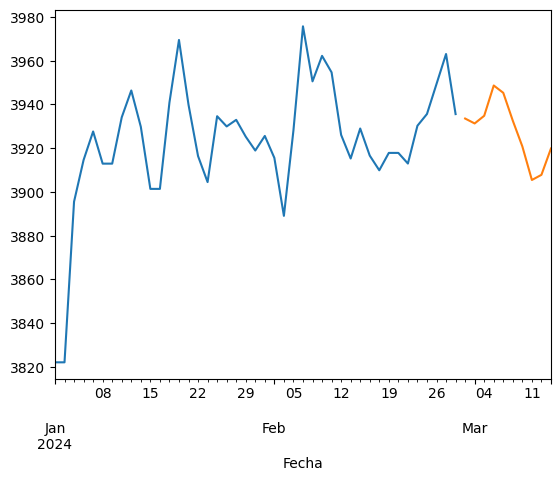

In [14]:
X = trm.drop(['TRM'], axis=1)
y = trm['TRM']

horizonte = 10
X_train = X.iloc[:-horizonte]
X_test = X.iloc[-horizonte:]
y_train = y.iloc[:-horizonte]
y_test = y.iloc[-horizonte:]

y_train.loc['2024'].plot(label='Train')
y_test.plot(label='Test');

In [15]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8379 entries, 1992-01-17 to 2024-02-28
Freq: B
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TRM-1            8379 non-null   float64
 1   TRM-2            8379 non-null   float64
 2   TRM-3            8379 non-null   float64
 3   TRM-4            8379 non-null   float64
 4   TRM-5            8379 non-null   float64
 5   TRM-6            8379 non-null   float64
 6   TRM-7            8379 non-null   float64
 7   TRM-8            8379 non-null   float64
 8   TRM-9            8379 non-null   float64
 9   TRM-10           8379 non-null   float64
 10  TRM-11           8379 non-null   float64
 11  TRM-12           8379 non-null   float64
 12  TRM-13           8379 non-null   float64
 13  TRM-14           8379 non-null   float64
 14  TRM-15           8379 non-null   float64
 15  TRM-16           8379 non-null   float64
 16  TRM-17           8379 non-null   f

Ahora vamos a entrenar un modelo de boosting, usando como métricas el MAPE (Error Porcentual Absoluto Medio) y el RMSE.

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

model = DecisionTreeRegressor(random_state=1)

model.fit(X_train, y_train)

print(f'MAPE train set: {mean_absolute_percentage_error(y_train, model.predict(X_train)):.4f}')
print(f'RMSE train set: {root_mean_squared_error(y_train, model.predict(X_train)):.4f}')

print(f'MAPE test set: {mean_absolute_percentage_error(y_test, model.predict(X_test)):.4f}')
print(f'RMSE test set: {root_mean_squared_error(y_test, model.predict(X_test)):.4f}')

MAPE train set: 0.0000
RMSE train set: 0.0000
MAPE test set: 0.0039
RMSE test set: 18.4743


En la gráfica de abajo se observan los pronósticos versus los datos reales:

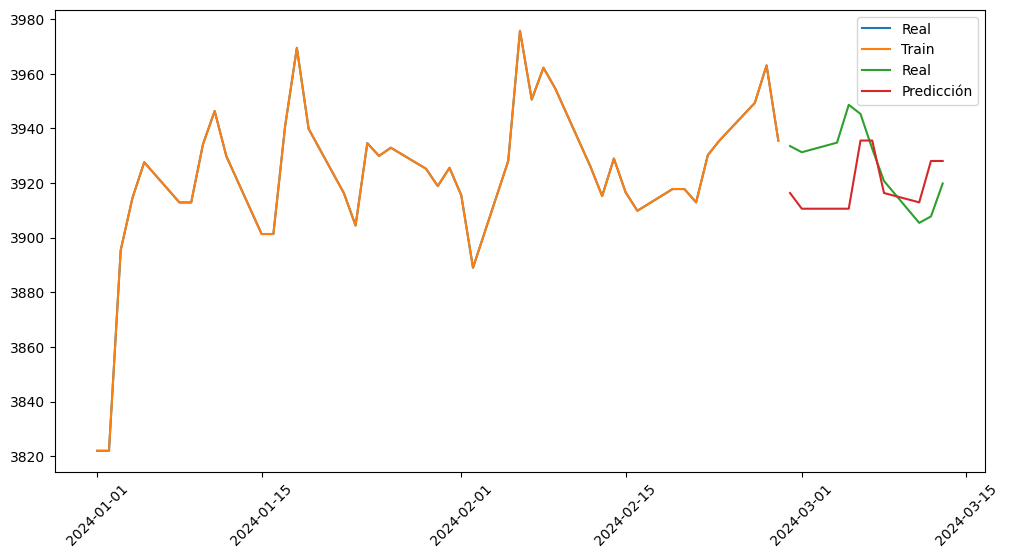

In [35]:
y_pred = model.predict(X_test)
y_est = model.predict(X_train.loc['2024'])
y_2024 = y_train.loc['2024']

plt.figure(figsize=(12, 6))
plt.plot(y_2024.index, y_2024, label='Real')
plt.plot(y_2024.index, y_est, label='Train')
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_test.index, y_pred, label='Predicción')
plt.legend()
plt.xticks(rotation=45);

Los coeficientes de este modelo son:

In [36]:
trm_features = pd.DataFrame({'Feature': X_train.columns, 'Coeficientes': model.feature_importances_})
trm_features.sort_values('Coeficientes', ascending=False)

,Feature,Coeficientes
0,TRM-1,0.997163
26,TRM-27,0.001915
4,TRM-5,0.000513
8,TRM-9,0.000063
9,TRM-10,0.000030
1,TRM-2,0.000022
30,rolling_7d_mean,0.000018
2,TRM-3,0.000018
3,TRM-4,0.000016
7,TRM-8,0.000014


## Sintonización de hiperparámetros

Para sintonizar hiperparámetros por validación cruzada debemos cuidarnos nuevamente de usar datos futuros para hacer predicciones, así que no se puede usar el método estándar de partición en folds. En vez de esto se recomienda usar el método `TimeSeriesSplit` que siempre tomara como subconjunto de validación los datos más recientes.

In [37]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform

dist = {
    'max_depth':[3,4,5,6,7,8,9,10],
    'min_samples_split':[2,3,4,5,6,7,8,9,10],
    }

ts_cv = TimeSeriesSplit(n_splits=5,
                        test_size=10,
                        gap=10
                        )

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    cv=ts_cv,
    scoring='neg_root_mean_squared_error',
    n_iter=2
    )

random_search.fit(X_train, y_train)

print(f'RMSE de validación: {-random_search.best_score_:.2f} with {random_search.best_params_}')
print(f'RMSE train set: {root_mean_squared_error(y_train, random_search.predict(X_train)):.4f}')
print(f'RMSE test set: {root_mean_squared_error(y_test, random_search.predict(X_test)):.4f}')

RMSE de validación: 24.86 with {'min_samples_split': 2, 'max_depth': 10}
RMSE train set: 11.3511
RMSE test set: 8.6434


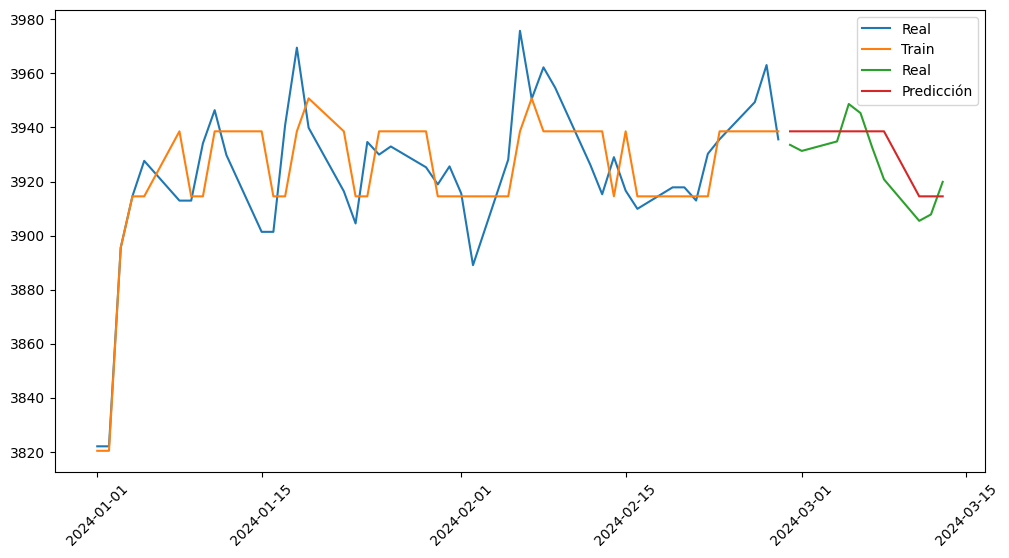

In [38]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_est = best_model.predict(X_train.loc['2024'])
y_2024 = y_train.loc['2024']

plt.figure(figsize=(12, 6))
plt.plot(y_2024.index, y_2024, label='Real')
plt.plot(y_2024.index, y_est, label='Train')
plt.plot(y_test.index, y_test, label='Real')
plt.plot(y_test.index, y_pred, label='Predicción')
plt.legend()
plt.xticks(rotation=45);

Los coeficientes de este modelo son:

In [39]:
trm_features = pd.DataFrame({'Feature': X_train.columns, 'Coeficientes': best_model.feature_importances_})
trm_features.sort_values('Coeficientes', ascending=False).head(20)

,Feature,Coeficientes
0,TRM-1,0.997275
17,TRM-18,0.001911
4,TRM-5,0.000505
8,TRM-9,0.000053
9,TRM-10,0.000023
19,TRM-20,0.000020
7,TRM-8,0.000015
30,rolling_7d_mean,0.000014
1,TRM-2,0.000012
2,TRM-3,0.000011


# Mejoras en la evaluación de modelos de pronóstico

La forma tradicional de evaluar un modelo de pronóstico, que fue la usada arriba, puede no ser realista, y puede tener desempeños inflados, porque en la vida real (en producción), los datos para predecir más allá del primer valor en la ventana de predicción no están disponibles.

Por esta razón se han desarrollado otros enfoques paa evaluar estos modelos que son más realistas. Entre estos están:

- **Predicción Recursiva**: Simular el entorno real haciendo predicciones paso a paso, alimentando al modelo con sus propias predicciones en lugar de los valores reales.
- **Walk-Forward Validation (WFV)**: similar al anterior solo que los modelos se reentrenan en cada paso.
- **Predicción Directa para un Horizonte Fijo**: Entrenar el modelo para predecir directamente varios pasos hacia el futuro (por ejemplo, los próximos 5 o 10 puntos).